# Coupled Harmonic Oscillator

This notebook builds a small mechanical system — two masses connected by springs and dampers, with one mass driven by an external, time-varying force — and simulates it with `scipy.integrate.solve_ivp`.

It also defines a reusable **state-advance function** that propagates the system from time $t$ to $t + dt$. That function is written so it can later be used as the forecast step inside an **Ensemble Kalman Filter (EnKF)**, where each ensemble member is a slightly different state/parameter combination that needs to be advanced forward in time.

## Physical setup

```
wall --[k1, c1]-- mass1 --[k2, c2]-- mass2 --(external force F(t))
```

- `mass1` is attached to a fixed wall by a spring (`k1`) and a damper in parallel (`c1`).
- `mass1` and `mass2` are connected to each other by a coupling spring (`k2`) and damper (`c2`).
- `mass2` is not attached to anything else — instead it is driven by an external force $F(t)$.

The figure below sketches this setup.

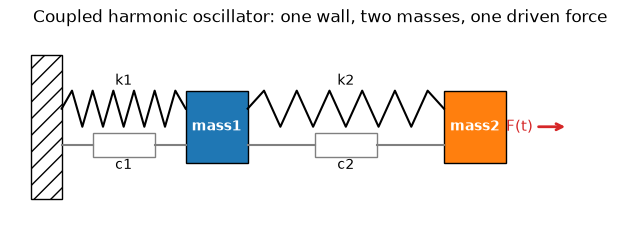

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def draw_spring(ax, x_start, x_end, y, num_coils=6, height=0.15):
    """Draw a simple zig-zag spring between two x positions at height y."""
    xs = np.linspace(x_start, x_end, num_coils * 2 + 1)
    ys = np.array([y] + [y + height * ((-1) ** i) for i in range(len(xs) - 2)] + [y])
    ax.plot(xs, ys, color="black", linewidth=1.5)


def draw_damper(ax, x_start, x_end, y):
    """Draw a simple damper (dashpot) symbol between two x positions at height y."""
    x_mid = (x_start + x_end) / 2
    ax.plot([x_start, x_mid - 0.3], [y, y], color="gray", linewidth=1.5)
    ax.plot([x_mid + 0.3, x_end], [y, y], color="gray", linewidth=1.5)
    ax.add_patch(plt.Rectangle((x_mid - 0.3, y - 0.1), 0.6, 0.2, fill=False, color="gray"))


figure, ax = plt.subplots(figsize=(8, 2.5))

# Wall (hatched rectangle on the left)
ax.add_patch(plt.Rectangle((-0.3, -0.6), 0.3, 1.2, hatch="//", fill=False))

# Masses
mass1_x, mass2_x = 1.5, 4.0
ax.add_patch(plt.Rectangle((mass1_x - 0.3, -0.3), 0.6, 0.6, facecolor="tab:blue", edgecolor="black"))
ax.add_patch(plt.Rectangle((mass2_x - 0.3, -0.3), 0.6, 0.6, facecolor="tab:orange", edgecolor="black"))
ax.text(mass1_x, 0, "mass1", ha="center", va="center", fontsize=10, color="white", weight="bold")
ax.text(mass2_x, 0, "mass2", ha="center", va="center", fontsize=10, color="white", weight="bold")

# Wall-to-mass1 spring and damper (k1, c1)
draw_spring(ax, 0.0, mass1_x - 0.3, y=0.15)
draw_damper(ax, 0.0, mass1_x - 0.3, y=-0.15)
ax.text((0 + mass1_x - 0.3) / 2, 0.35, "k1", ha="center")
ax.text((0 + mass1_x - 0.3) / 2, -0.35, "c1", ha="center")

# Coupling spring and damper (k2, c2)
draw_spring(ax, mass1_x + 0.3, mass2_x - 0.3, y=0.15)
draw_damper(ax, mass1_x + 0.3, mass2_x - 0.3, y=-0.15)
ax.text((mass1_x + mass2_x) / 2, 0.35, "k2", ha="center")
ax.text((mass1_x + mass2_x) / 2, -0.35, "c2", ha="center")

# External force arrow on mass2
ax.annotate(
    "F(t)", xy=(mass2_x + 0.9, 0), xytext=(mass2_x + 0.3, 0),
    arrowprops=dict(arrowstyle="->", color="tab:red", linewidth=2),
    fontsize=11, color="tab:red", va="center",
)

ax.set_xlim(-0.5, mass2_x + 1.5)
ax.set_ylim(-0.8, 0.8)
ax.axis("off")
ax.set_title("Coupled harmonic oscillator: one wall, two masses, one driven force")
plt.show()

## Equations of motion

Applying Newton's second law ($F = ma$) to each mass, with the coupling spring/damper force acting equally and oppositely on both masses:

$$
m_1 \ddot{x}_1 = -k_1 x_1 - c_1 \dot{x}_1 \;-\; k_2 (x_1 - x_2) - c_2(\dot{x}_1 - \dot{x}_2)
$$

$$
m_2 \ddot{x}_2 = k_2 (x_1 - x_2) + c_2(\dot{x}_1 - \dot{x}_2) + F(t)
$$

where:
- $x_1, x_2$ — displacement of mass1/mass2 from their equilibrium position [m]
- $\dot x_1, \dot x_2$ — velocities [m/s]
- $\ddot x_1, \ddot x_2$ — accelerations [m/s²]
- $F(t)$ — external, time-varying force applied only to mass2 [N]

For numerical integration we rewrite this as a first-order system in the state vector $\mathbf{s} = (x_1, v_1, x_2, v_2)$:

$$
\dot{\mathbf s} = \begin{pmatrix} v_1 \\ a_1 \\ v_2 \\ a_2 \end{pmatrix}, \qquad
a_1 = \frac{-k_1 x_1 - c_1 v_1 - k_2 (x_1 - x_2) - c_2 (v_1 - v_2)}{m_1}, \qquad
a_2 = \frac{k_2 (x_1 - x_2) + c_2 (v_1 - v_2) + F(t)}{m_2}
$$

This is exactly the form `scipy.integrate.solve_ivp` expects: a function that returns $\dot{\mathbf s}$ given $t$ and $\mathbf s$.

## Parameters

All physical constants and initial conditions are gathered here so the whole simulation can be reconfigured by changing a handful of named values.

In [2]:
# Masses [kg]
mass1 = 1.0
mass2 = 1.0

# Spring constants [N/m]
k1 = 4.0    # spring connecting mass1 to the wall
k2 = 1.0    # coupling spring connecting mass1 and mass2

# Damping coefficients [N*s/m], one damper per spring, in parallel with it
# (set to 0 for no damping / undamped motion)
c1 = 0.5    # damper in parallel with the wall spring (k1)
c2 = 0.5    # damper in parallel with the coupling spring (k2)

# External force on mass2 [N]: a periodic step-wise (square-like) force that
# alternates between +amplitude and -amplitude every half period. Each cycle's
# period and amplitude are randomly jittered by a small fraction, so the wave
# still looks like a square wave but is never perfectly regular.
force_amplitude = 1.0          # base magnitude of the applied force [N]
force_amplitude_jitter = 0.15  # max random amplitude variation, as a fraction of force_amplitude (0 = none)
force_period = 10              # base time for one full square-wave cycle [s]
force_period_jitter = 0.15     # max random period variation, as a fraction of force_period (0 = none)
force_random_seed = 42         # seed for reproducible randomness
force_transition_time = 0.1    # time constant [s] controlling how gradual each sign switch is
                                # (larger = slower, more rounded-off drops; smaller = closer to an abrupt jump)

# Initial conditions
x1_initial = 1.0   # initial displacement of mass1 from its equilibrium [m]
v1_initial = 0.0   # initial velocity of mass1 [m/s]
x2_initial = 0.0   # initial displacement of mass2 from its equilibrium [m]
v2_initial = 0.0   # initial velocity of mass2 [m/s]

# Equilibrium positions [m], measured from the wall. Used only to convert
# each mass's displacement (x1, x2) into an absolute position for plotting.
mass1_equilibrium_position = 2.0   # where mass1 sits at rest, from the wall
mass2_equilibrium_position = 5.0   # where mass2 sits at rest, from the wall

# Simulation time settings
start_time = 0.0        # simulation start time [s]
end_time = 50.0         # simulation end time [s]
num_time_points = 10000  # number of points at which to evaluate the solution

## External force on mass2

$F(t)$ is built in two steps:

1. **A square-like base force.** Time is divided into cycles; during the first half of each cycle the force is held at $+A_i$, during the second half at $-A_i$. Both the cycle's period $T_i$ and amplitude $A_i$ are randomly jittered by a small fraction each cycle, so the wave keeps its square shape but no two cycles are exactly alike:
$$
T_i = T_{\text{base}}\,(1 + \epsilon_i), \qquad A_i = A_{\text{base}}\,(1 + \eta_i), \qquad \epsilon_i, \eta_i \sim \mathcal{U}(-\delta, \delta)
$$

2. **Smoothing each sign switch.** Instead of an instantaneous jump at every switch time $\tau_i$, each transition is replaced with a gradual $\tanh$ ramp of width `force_transition_time` ($\theta$):
$$
F(t) = F_0 + \sum_i \Delta F_i \cdot \frac{1}{2}\Big(1 + \tanh\Big(\frac{t - \tau_i}{\theta}\Big)\Big)
$$
where $F_0$ is the force level at the very start and $\Delta F_i$ is the change in level at switch $\tau_i$. Because $\tanh$ is continuous and differentiable everywhere, so is $F(t)$ — there are no sudden jumps for the ODE solver to struggle with.

In [3]:
# Generate the times at which the force switches sign (every half period) and
# the amplitude held until each switch. Each cycle's period and amplitude are
# independently jittered by a random fraction, so the wave keeps its square
# shape but drifts slightly from one cycle to the next.
_force_rng = np.random.default_rng(force_random_seed)

_switch_times = [start_time]     # boundaries between constant-force segments
_segment_amplitudes = []         # force value held during each segment

_current_time = start_time
while _current_time < end_time:
    _cycle_period = force_period * (1 + _force_rng.uniform(-force_period_jitter, force_period_jitter))
    _cycle_amplitude = force_amplitude * (1 + _force_rng.uniform(-force_amplitude_jitter, force_amplitude_jitter))
    _half_period = _cycle_period / 2

    _segment_amplitudes.append(_cycle_amplitude)     # first half of the cycle: +amplitude
    _switch_times.append(_current_time + _half_period)

    _segment_amplitudes.append(-_cycle_amplitude)    # second half of the cycle: -amplitude
    _switch_times.append(_current_time + _cycle_period)

    _current_time += _cycle_period

_switch_times = np.array(_switch_times)
_segment_amplitudes = np.array(_segment_amplitudes)

# Recast the step-wise waveform as a smooth sum of tanh transitions: starting
# from the first segment's level, add each subsequent level change as a
# gradual tanh ramp centered on its switch time instead of an instant jump.
# tanh is continuous and differentiable everywhere, so the resulting force is
# too, while still looking like a (rounded-off) square wave.
_base_level = _segment_amplitudes[0]
_transition_times = _switch_times[1:-1]        # switch times between segments (excludes the start and the trailing end)
_level_changes = np.diff(_segment_amplitudes)  # how much the level changes at each transition


def external_force_on_mass2(t):
    """
    Smoothed, square-like force applied to mass2.

    Same jittered period/amplitude levels as a square wave, but each sign
    switch is a gradual tanh ramp (width set by force_transition_time)
    rather than an instant jump, so the force is continuous and
    differentiable everywhere.
    """
    t_array = np.atleast_1d(np.asarray(t, dtype=float))
    # Each transition contributes level_change * 0.5*(1 + tanh((t - transition_time) / force_transition_time)),
    # which smoothly rises from 0 (well before the transition) to level_change (well after it).
    ramps = 0.5 * (1 + np.tanh((t_array[:, None] - _transition_times[None, :]) / force_transition_time))
    force_values = _base_level + ramps @ _level_changes
    return force_values.item() if np.isscalar(t) else force_values

Let's visualize $F(t)$ on its own before running the full simulation, to confirm it looks like a smoothed, jittered square wave.

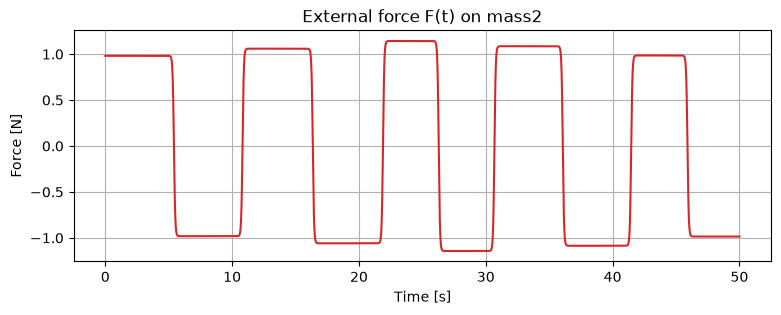

In [4]:
preview_times = np.linspace(start_time, end_time, num_time_points)

plt.figure(figsize=(9, 3))
plt.plot(preview_times, external_force_on_mass2(preview_times), color="tab:red")
plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.title("External force F(t) on mass2")
plt.grid(True)
plt.show()

## Equations of motion function

`coupled_oscillator_equations` implements the first-order system derived above, in the exact form `solve_ivp` requires: a function `f(t, state)` returning `d(state)/dt`.

In [5]:
def coupled_oscillator_equations(t, state):
    """
    Compute the time derivative of the system state.

    The state vector is [x1, v1, x2, v2], where x1/x2 are the mass
    positions and v1/v2 are their velocities. This function returns
    [v1, a1, v2, a2], i.e. the derivative of each state variable, which is
    what solve_ivp needs to advance the solution forward in time.
    """
    x1, v1, x2, v2 = state

    # Relative displacement and velocity across the coupling spring, used by
    # both its spring force and its damper force.
    coupling_displacement = x1 - x2
    coupling_velocity = v1 - v2

    # Net force on each mass is the sum of its spring force(s), damper
    # force(s), and any external force acting on it.
    force1 = -k1 * x1 - c1 * v1 - k2 * coupling_displacement - c2 * coupling_velocity
    force2 = k2 * coupling_displacement + c2 * coupling_velocity + external_force_on_mass2(t)

    # Acceleration = force / mass (Newton's second law).
    a1 = force1 / mass1
    a2 = force2 / mass2

    return [v1, a1, v2, a2]

## A reusable state-advance function

For later use in a data-assimilation setting (e.g. the forecast step of an Ensemble Kalman Filter), it's useful to have a self-contained function that:

- takes an explicit state $(x_1, v_1, x_2, v_2)$ and explicit parameters $(m_1, m_2, k_1, k_2, c_1, c_2)$ — not global variables, so each ensemble member can carry its own values,
- takes a current time $t$ and a step size $dt$ that does **not** need to be small,
- and returns the state at $t + dt$.

`advance_coupled_oscillator_state` does this by calling `solve_ivp` internally over the interval $[t, t+dt]$ with adaptive step-size control, so accuracy is preserved even for a large $dt$ (e.g. the time between two observations).

In [6]:
def advance_coupled_oscillator_state(
    x1, v1, x2, v2, m1, m2, k1, k2, c1, c2, t, dt,
    method="RK45", rtol=1e-6, atol=1e-9,
):
    """
    Advance the coupled-oscillator state from time t to time t + dt.

    Takes the current state (x1, v1, x2, v2), the physical parameters
    (m1, m2, k1, k2, c1, c2), the current time t, and a time step dt, and
    returns the state (x1, v1, x2, v2) at time t + dt. dt does not need to
    be small: this integrates the equations of motion with
    scipy.integrate.solve_ivp (adaptive step size) rather than taking a
    single fixed step, so it stays accurate even for a large dt. This makes
    it suitable as the forecast step for an ensemble member with its own
    state and parameters, e.g. in an EnKF loop.

    The external force on mass2, external_force_on_mass2(t), is looked up
    the same way as in coupled_oscillator_equations.
    """

    def state_derivative(time_value, state):
        x1_, v1_, x2_, v2_ = state

        coupling_displacement = x1_ - x2_
        coupling_velocity = v1_ - v2_

        force1 = -k1 * x1_ - c1 * v1_ - k2 * coupling_displacement - c2 * coupling_velocity
        force2 = k2 * coupling_displacement + c2 * coupling_velocity + external_force_on_mass2(time_value)

        a1 = force1 / m1
        a2 = force2 / m2

        return [v1_, a1, v2_, a2]

    step_solution = solve_ivp(
        fun=state_derivative,
        t_span=(t, t + dt),
        y0=[x1, v1, x2, v2],
        method=method,
        rtol=rtol,
        atol=atol,
    )

    x1_next, v1_next, x2_next, v2_next = step_solution.y[:, -1]
    return x1_next, v1_next, x2_next, v2_next

### Quick sanity check

Advance the initial state by a single 5-second step and confirm we get a sensible result.

In [7]:
x1_check, v1_check, x2_check, v2_check = advance_coupled_oscillator_state(
    x1=x1_initial, v1=v1_initial, x2=x2_initial, v2=v2_initial,
    m1=mass1, m2=mass2, k1=k1, k2=k2, c1=c1, c2=c2,
    t=start_time, dt=5.0,
)
print(f"State after a 5s step: x1={x1_check:.4f}, v1={v1_check:.4f}, x2={x2_check:.4f}, v2={v2_check:.4f}")

State after a 5s step: x1=0.3056, v1=0.0214, x2=1.6533, v2=-0.3524


## Running the full simulation

Now integrate the equations of motion over the full simulation window with `solve_ivp`, using a `max_step` small enough to resolve both the shortest possible cycle and the force's transition width.

In [8]:
initial_state = [x1_initial, v1_initial, x2_initial, v2_initial]
time_points = np.linspace(start_time, end_time, num_time_points)

solution = solve_ivp(
    fun=coupled_oscillator_equations,
    t_span=(start_time, end_time),
    y0=initial_state,
    t_eval=time_points,
    method="RK45",  # adaptive-step Runge-Kutta method
    max_step=min(force_period * (1 - force_period_jitter), force_transition_time) / 20,  # resolve the shortest cycle/transition
    rtol=1e-6,      # relative tolerance for adaptive step size
    atol=1e-9,      # absolute tolerance for adaptive step size
)

time = solution.t
x1 = solution.y[0]
v1 = solution.y[1]
x2 = solution.y[2]
v2 = solution.y[3]
applied_force = external_force_on_mass2(time)

# Absolute positions of each mass (equilibrium position + displacement),
# used for plotting instead of raw displacement.
position1 = mass1_equilibrium_position + x1
position2 = mass2_equilibrium_position + x2

## Results

Three views of the simulation:
1. Absolute position of each mass over time (equilibrium position + displacement)
2. Velocity of each mass over time
3. The external force actually applied to mass2 over the simulation window

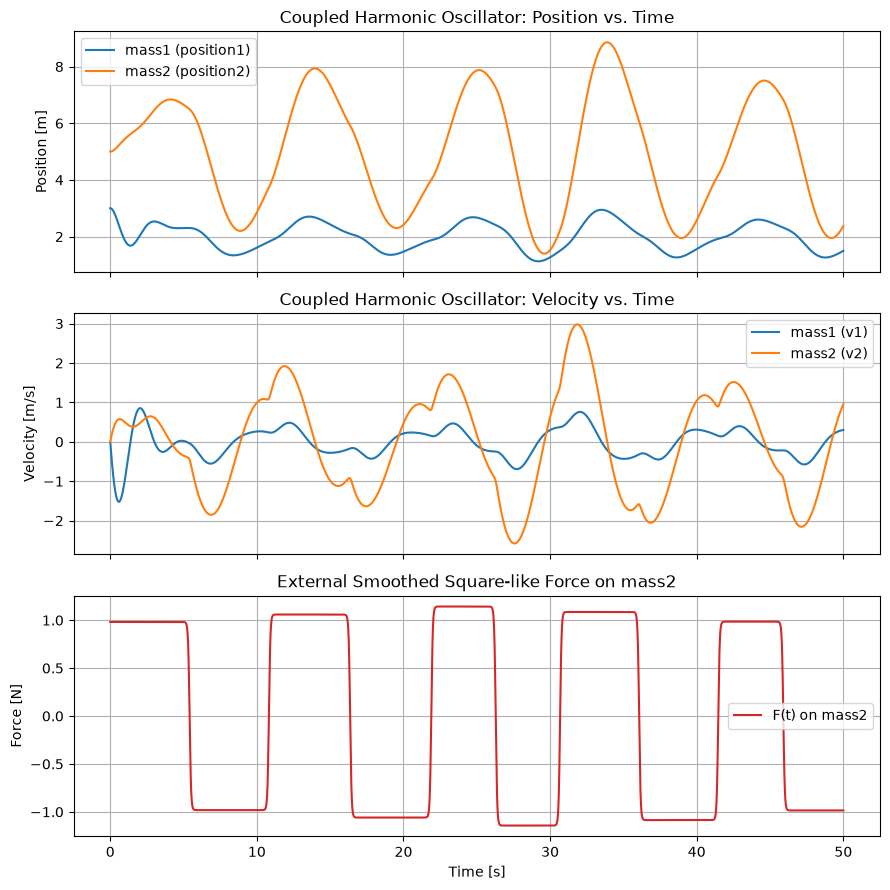

In [9]:
figure, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(time, position1, label="mass1 (position1)")
axes[0].plot(time, position2, label="mass2 (position2)")
axes[0].set_ylabel("Position [m]")
axes[0].set_title("Coupled Harmonic Oscillator: Position vs. Time")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(time, v1, label="mass1 (v1)")
axes[1].plot(time, v2, label="mass2 (v2)")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].set_title("Coupled Harmonic Oscillator: Velocity vs. Time")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(time, applied_force, label="F(t) on mass2", color="tab:red")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Force [N]")
axes[2].set_title("External Smoothed Square-like Force on mass2")
axes[2].legend()
axes[2].grid(True)

figure.tight_layout()
plt.show()